In [117]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
import chunkbench.path_utils as pu
import numpy as np
import os

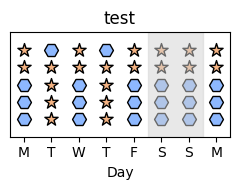

/tmp/ipykernel_3750725/3430369097.py:121: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


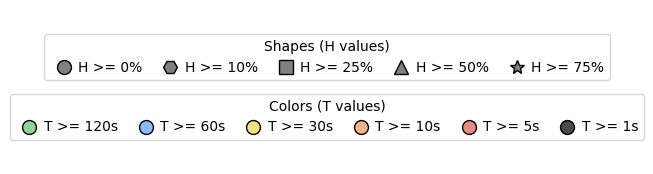

In [185]:
class Chunk:

    H_SHAPE_MAP = {
        0: "o",
        10: "H",
        25: "s",
        50: "^",
        75: "*",
    }
    # T_COLOR_MAP = {
    #     120: "green",
    #     60: "blue",
    #     30: "yellow",
    #     10: "orange",
    #     5: "red",
    #     1: "black",
    # }

    # For the T_color_map, use the corresponding muted colors:
    # T_COLOR_MAP = {
    #     120: "lightgreen",
    #     60: "lightblue",
    #     30: "lightyellow",
    #     10: "lightsalmon",
    #     5: "lightcoral",
    #     1: "darkgray",
    # }
    T_COLOR_MAP = {
        120: "#8FD694",  # soft green
        60: "#8DB8FF",  # light blue
        30: "#F7E17D",  # soft yellow
        10: "#F4B383",  # warm peach/orange
        5: "#E78C84",  # muted red
        1: "#4A4A4A",  # soft black / dark gray
    }

    def __init__(self, H: int, T: int):
        """
        Initialize a new chunk.

        Parameters:
            H: The percentage of heavy queries (0-100).
            T: The mean query interarrival time in seconds.

        Raises:
            ValueError: If H is not between 0 and 100 or if T is not positive.
        """
        if not (0 <= H <= 100):
            raise ValueError("H must be between 0 and 100.")
        if T <= 0:
            raise ValueError("T must be a positive number.")

        self.H = H
        self.T = T

    def color(self) -> str:
        """Get the color associated with the chunk's T value."""
        for t_threshold, color in sorted(self.T_COLOR_MAP.items(), reverse=True):
            if self.T >= t_threshold:
                return color
        return "black"  # Default color if no thresholds match

    def shape(self) -> str:
        """Get the shape associated with the chunk's H value."""
        for h_threshold, shape in sorted(self.H_SHAPE_MAP.items(), reverse=True):
            if self.H >= h_threshold:
                return shape
        return "o"  # Default shape if no thresholds match

    @staticmethod
    def plot_legend():
        fig_legend, ax = plt.subplots(figsize=(3.5, 2))
        ax.axis("off")

        shape_legend_elements = [
            plt.Line2D(
                [0],
                [0],
                marker=shape,
                color="w",
                label=f"H >= {h_threshold}%",
                markerfacecolor="gray",
                markersize=10,
                markeredgecolor="black",
            )
            for h_threshold, shape in Chunk.H_SHAPE_MAP.items()
        ]
        color_legend_elements = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=f"T >= {t_threshold}s",
                markerfacecolor=color,
                markersize=10,
                markeredgecolor="black",
            )
            for t_threshold, color in Chunk.T_COLOR_MAP.items()
        ]

        first_legend = ax.legend(
            handles=shape_legend_elements,
            title="Shapes (H values)",
            loc="lower center",
            bbox_to_anchor=(0.5, 0.5),
            columnspacing=1,
            handletextpad=0.05,
            ncols=len(Chunk.H_SHAPE_MAP),
        )
        ax.add_artist(first_legend)
        ax.legend(
            handles=color_legend_elements,
            title="Colors (T values)",
            loc="upper center",
            bbox_to_anchor=(0.5, 0.5),
            columnspacing=1,
            handletextpad=0.05,
            ncols=len(Chunk.T_COLOR_MAP),
        )
        plt.tight_layout()
        plt.savefig(
            os.path.join(pu.DATA_PATH, "composite_traces", "legend.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


class DaySpec:

    def __init__(self, chunk: Chunk, repetitions: int):
        """
        Initialize a new DaySpec.

        Parameters:
            chunk: A Chunk object representing the chunk type.
            repetitions: The number of times this chunk should be repeated in the day.

        Raises:
            ValueError: If repetitions is not a positive integer.
        """
        if repetitions <= 0:
            raise ValueError("repetitions must be a positive integer.")

        self.chunk = chunk
        self.repetitions = repetitions

    def flat(self) -> list[Chunk]:
        """Get a flat list of chunks represented by this DaySpec."""
        return [self.chunk] * self.repetitions


class Day:

    def __init__(self, specs: list[DaySpec]):
        """
        Initialize a new day with a list of chunks.

        Parameters:
            specs: A list of DaySpec objects representing the day's workload.
        """
        self.specs = specs
        self.chunks = [chunk for spec in specs for chunk in spec.flat()]

    def chunks(self) -> list[Chunk]:
        """Get the list of chunks in the day."""
        return self.chunks

    def colors(self) -> list[str]:
        """Get a list of colors for all chunks in the day."""
        return [chunk.color() for chunk in self.chunks]

    def shapes(self) -> list[str]:
        """Get a list of shapes for all chunks in the day."""
        return [chunk.shape() for chunk in self.chunks]


class CompositeWorkload:

    def __init__(self, name: str, days: list[Day], monday_index: int = 0):
        """
        Initialize a new CompositeWorkload.

        Parameters:
            name: A string representing the name of the composite workload.
            days: A list of Day objects representing the workload over multiple days.
            monday_index: An integer representing the index of the first Monday in the days list.

        Raises:
            ValueError: If monday_index is not between 0 and min(7, number of days).
        """
        self.name = name
        self.days = days
        self.monday_index = monday_index

        if not (0 <= self.monday_index < min(len(self.days), 7)):
            raise ValueError(
                "monday_index must be between 0 and min(7, number of days)."
            )

    def day_initials(self) -> list[str]:
        """Get the initials of the days of the week starting from monday_index."""
        day_names = ["M", "T", "W", "T", "F", "S", "S"]
        return [
            f"{day_names[(self.monday_index + i) % 7]}" for i in range(len(self.days))
        ]

    def plot(self):
        """Plot the composite workload over the days. For each day, stack the chunks vertically."""
        eff_num_days = max(7, len(self.days))
        fig_width = eff_num_days * 0.25 + 0.5
        fig_height = max(5, max(len(day.chunks) for day in self.days)) * 0.2 + 1

        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        # Plot each chunk in its respective day position
        for day_idx, day in enumerate(self.days):
            for chunk_idx, chunk in enumerate(day.chunks):
                ax.scatter(
                    [day_idx],
                    [chunk_idx],
                    color=chunk.color(),
                    marker=chunk.shape(),
                    s=100,
                    edgecolors="black",
                )

        # Shade the background of the weekends.
        weekend_day_idxs = [
            i for i in range(len(self.days)) if (self.monday_index + i) % 7 in [5, 6]
        ]
        weekend_starts_ends = []
        for i in range(len(weekend_day_idxs)):
            if i == 0 or weekend_day_idxs[i] != weekend_day_idxs[i - 1] + 1:
                weekend_starts_ends.append([weekend_day_idxs[i], weekend_day_idxs[i]])
            else:
                weekend_starts_ends[-1][1] = weekend_day_idxs[i]

        for start, end in weekend_starts_ends:
            ax.axvspan(start - 0.5, end + 0.5, color="lightgray", alpha=0.5)

        ax.set_xlabel("Day")
        ax.set_xticks(range(eff_num_days))
        ax.set_xticklabels(self.day_initials() + [""] * (eff_num_days - len(self.days)))
        ax.set_yticks([])
        ax.set_title(self.name)
        ax.set_ylim(-1, max(len(day.chunks) for day in self.days))
        ax.set_xlim(-0.5, eff_num_days - 0.5)
        plt.tight_layout()
        plt.savefig(
            os.path.join(pu.DATA_PATH, "composite_traces", f"{self.name}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    def plot_legend(self):
        Chunk.plot_legend()


chunk1 = Chunk(H=10, T=60)
chunk2 = Chunk(H=75, T=10)
day1 = Day([DaySpec(chunk1, 3), DaySpec(chunk2, 2)])
day2 = Day([DaySpec(chunk2, 4), DaySpec(chunk1, 1)])
composite_workload = CompositeWorkload(
    "test",
    [
        day1,
        day2,
        day1,
        day2,
        day1,
        day1,
        day1,
        day1,
    ],
)
composite_workload.plot()
composite_workload.plot_legend()

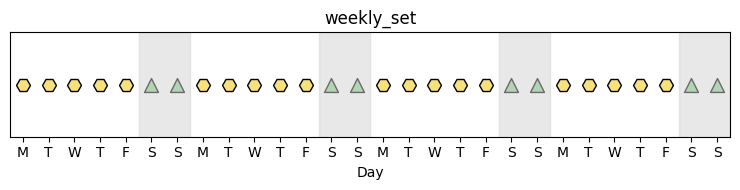

In [174]:
# weekly_set
monday_chunk = Chunk(H=10, T=30)
weekend_chunk = Chunk(H=50, T=120)
weekday = Day([DaySpec(monday_chunk, 1)])
weekend = Day([DaySpec(weekend_chunk, 1)])
weekly_set = CompositeWorkload('weekly_set',
    ([weekday] * 5 + [weekend] * 2) *4
)
weekly_set.plot()

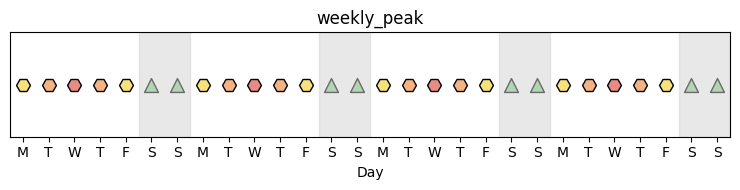

In [175]:
# weekly_peak
monday_chunk = Chunk(H=10, T=30)
tuesday_chunk = Chunk(H=10, T=10)
wednesday_chunk = Chunk(H=10, T=5)
weekend_chunk = Chunk(H=50, T=120)

monday = Day([DaySpec(monday_chunk, 1)])
tuesday = Day([DaySpec(tuesday_chunk, 1)])
wednesday = Day([DaySpec(wednesday_chunk, 1)])
thursday = tuesday
friday = monday
weekend = Day([DaySpec(weekend_chunk, 1)])

weekly_peak = CompositeWorkload(
    "weekly_peak", ([monday, tuesday, wednesday, thursday, friday] + [weekend] * 2) * 4
)
weekly_peak.plot()

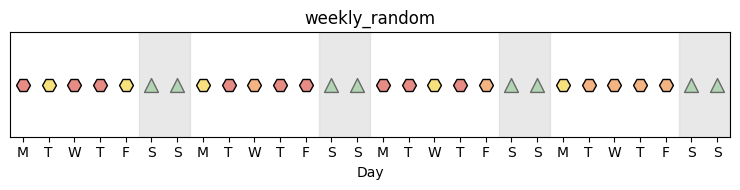

In [176]:
# weekly_random

light_weekday = Day([DaySpec(Chunk(10, 30), 1)])
medium_weekday = Day([DaySpec(Chunk(10, 10), 1)])
heavy_weekday = Day([DaySpec(Chunk(10, 5), 1)])

weekend = Day([DaySpec(Chunk(50, 120), 1)])


# Replace weekends with weekend days
np.random.seed(42)
weekdays = np.random.choice([light_weekday, medium_weekday, heavy_weekday], size=20)
days = []
for i in range(len(weekdays) // 5):
    days.extend(weekdays[i*5:(i+1)*5])
    days.extend([weekend, weekend])
weekly_random = CompositeWorkload(
    "weekly_random", 
    days
)
weekly_random.plot()

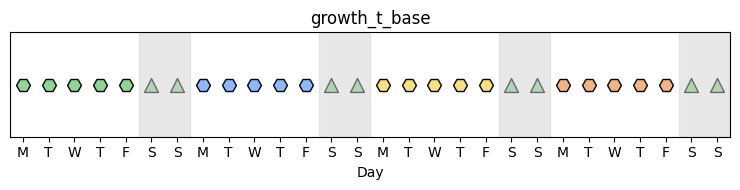

In [177]:
# Growth T base
first_week = [Day([DaySpec(Chunk(10, 120), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
second_week = [Day([DaySpec(Chunk(10, 60), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1  )])] * 2
third_week = [Day([DaySpec(Chunk(10, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
fourth_week = [Day([DaySpec(Chunk(10, 10), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
growth_t_base = CompositeWorkload(
    "growth_t_base", 
    first_week + second_week + third_week + fourth_week
)
growth_t_base.plot()

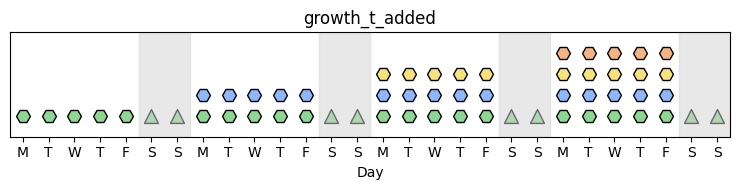

In [178]:
# Growth T added
first_week = [Day([DaySpec(Chunk(10, 120), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
second_week = [Day([DaySpec(Chunk(10, 120), 1), DaySpec(Chunk(10, 60), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1  )])] * 2
third_week = [Day([DaySpec(Chunk(10, 120), 1), DaySpec(Chunk(10, 60), 1), DaySpec(Chunk(10, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
fourth_week = [Day([DaySpec(Chunk(10, 120), 1), DaySpec(Chunk(10, 60), 1), DaySpec(Chunk(10, 30), 1), DaySpec(Chunk(10, 10), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
growth_t_added = CompositeWorkload(
    "growth_t_added", 
    first_week + second_week + third_week + fourth_week
)
growth_t_added.plot()

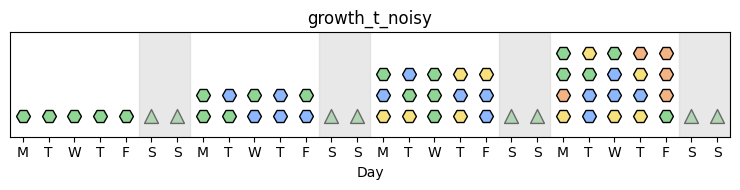

In [179]:
# Growth T noisy
np.random.seed(12)
first_week = [Day([DaySpec(Chunk(10, 120), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
second_week_t = [60]*5 + [120]*5
np.random.shuffle(second_week_t)
second_week = [
    Day([DaySpec(Chunk(10, second_week_t[2*i]), 1), DaySpec(Chunk(10, second_week_t[2*i+1]), 1)])
    for i in range(5)
] + [Day([DaySpec(Chunk(50, 120), 1  )])] * 2
third_week_t = ([30]*5 + [60]*5 + [120]*5)
np.random.shuffle(third_week_t)
third_week = [
    Day([DaySpec(Chunk(10, third_week_t[3*i]), 1), DaySpec(Chunk(10, third_week_t[3*i+1]), 1), DaySpec(Chunk(10, third_week_t[3*i+2]), 1)])
    for i in range(5)
] + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
fourth_week_t = ([10]*5 + [30]*5 + [60]*5 + [120]*5)
np.random.shuffle(fourth_week_t)
fourth_week = [
    Day([DaySpec(Chunk(10, fourth_week_t[4*i]), 1), DaySpec(Chunk(10, fourth_week_t[4*i+1]), 1), DaySpec(Chunk(10, fourth_week_t[4*i+2]), 1), DaySpec(Chunk(10, fourth_week_t[4*i+3]), 1)])
    for i in range(5)
] + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
growth_t_noisy = CompositeWorkload(
    "growth_t_noisy", 
    first_week + second_week + third_week + fourth_week
)
growth_t_noisy.plot()

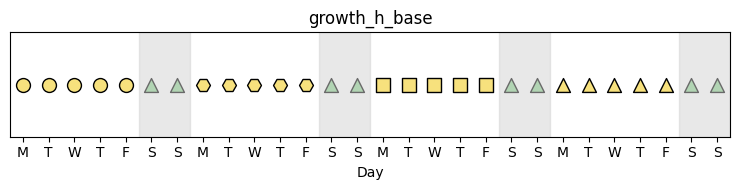

In [180]:
# Growth H base
first_week = [Day([DaySpec(Chunk(0, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
second_week = [Day([DaySpec(Chunk(10, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1  )])] * 2
third_week = [Day([DaySpec(Chunk(25, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
fourth_week = [Day([DaySpec(Chunk(50, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
growth_h_base = CompositeWorkload(
    "growth_h_base", 
    first_week + second_week + third_week + fourth_week
)
growth_h_base.plot()

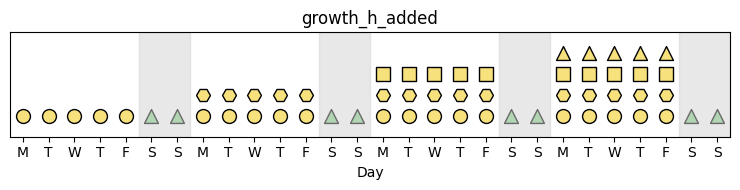

In [181]:
# Growth Η added
first_week = [Day([DaySpec(Chunk(0, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
second_week = [Day([DaySpec(Chunk(0, 30), 1), DaySpec(Chunk(10, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1  )])] * 2
third_week = [Day([DaySpec(Chunk(0, 30), 1), DaySpec(Chunk(10, 30), 1), DaySpec(Chunk(25, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
fourth_week = [Day([DaySpec(Chunk(0, 30), 1), DaySpec(Chunk(10, 30), 1), DaySpec(Chunk(25, 30), 1), DaySpec(Chunk(50, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
growth_h_added = CompositeWorkload(
    "growth_h_added", 
    first_week + second_week + third_week + fourth_week
)
growth_h_added.plot()

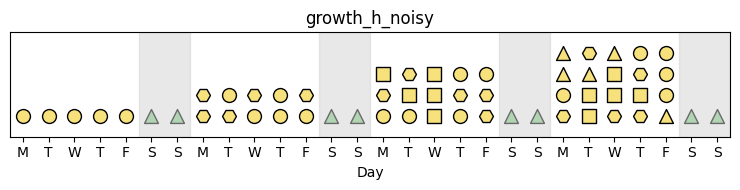

In [183]:
# Growth H noisy
np.random.seed(12)
first_week = [Day([DaySpec(Chunk(0, 30), 1)])] * 5 + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
second_week_h = [0]*5 + [10]*5
np.random.shuffle(second_week_h)
second_week = [
    Day([DaySpec(Chunk(second_week_h[2*i],30), 1), DaySpec(Chunk(second_week_h[2*i+1], 30), 1)])
    for i in range(5)
] + [Day([DaySpec(Chunk(50, 120), 1  )])] * 2
third_week_h = ([0]*5 + [10]*5 + [25]*5)
np.random.shuffle(third_week_h)
third_week = [
    Day([DaySpec(Chunk(third_week_h[3*i], 30), 1), DaySpec(Chunk(third_week_h[3*i+1], 30), 1), DaySpec(Chunk(third_week_h[3*i+2], 30), 1)])
    for i in range(5)
] + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
fourth_week_h = ([0]*5 + [10]*5 + [25]*5 + [50]*5)
np.random.shuffle(fourth_week_h)
fourth_week = [
    Day([DaySpec(Chunk(fourth_week_h[4*i], 30), 1), DaySpec(Chunk(fourth_week_h[4*i+1], 30), 1), DaySpec(Chunk(fourth_week_h[4*i+2], 30), 1), DaySpec(Chunk(fourth_week_h[4*i+3], 30), 1)])
    for i in range(5)
] + [Day([DaySpec(Chunk(50, 120), 1)])] * 2
growth_h_noisy = CompositeWorkload(
    "growth_h_noisy", 
    first_week + second_week + third_week + fourth_week
)
growth_h_noisy.plot()